# Task
Build a Decision Tree Classifier to predict whether a client will subscribe to a term deposit using the dataset "bank-additional-full.csv". The process should include loading and inspecting the data, preprocessing categorical features, splitting the data into training and testing sets, training the model, and evaluating its performance through metrics and visualizations like feature importance.

## Load and Inspect Dataset




In [ ]:
import pandas as pd

# Load the dataset from the local path since the URL is unavailable
file_path = '/content/bank-additional-full.csv'
df = pd.read_csv(file_path, sep=';')

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Inspect the dataset schema
print("\nDataset Info:")
df.info()

# Summary statistics for numerical features
print("\nSummary Statistics:")
display(df.describe())

First 5 rows of the dataset:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Data Preprocessing




In [ ]:
# 1. Convert the target variable 'y' to numeric values (yes -> 1, no -> 0)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# 2. Identify categorical features (excluding the target 'y')
# Based on df.info() from the previous step, categorical features are of object type
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features to encode: {categorical_features}")

# 3. Perform one-hot encoding on categorical features
# We use drop_first=True to avoid the dummy variable trap
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# 4. Create the feature matrix X by dropping the target column 'y'
X = df_encoded.drop('y', axis=1)

# 5. Create the target vector y
y = df_encoded['y']

print("\nPreprocessing complete.")
print(f"Shape of feature matrix X: {X.shape}")
print(f"Shape of target vector y: {y.shape}")
print("\nFirst 5 rows of the encoded features:")
display(X.head())

Categorical features to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Preprocessing complete.
Shape of feature matrix X: (41188, 53)
Shape of target vector y: (41188,)

First 5 rows of the encoded features:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


## Split Data into Train and Test Sets




In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the dimensions of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (32950, 53)
Shape of X_test: (8238, 53)
Shape of y_train: (32950,)
Shape of y_test: (8238,)


## Train Decision Tree Classifier




In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
# Setting random_state=42 ensures the results are reproducible
clf = DecisionTreeClassifier(random_state=42)

# Train the model using the training data
clf.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


## Evaluate Model and Visualize Results



Accuracy Score: 0.8869

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7303
           1       0.50      0.52      0.51       935

    accuracy                           0.89      8238
   macro avg       0.72      0.73      0.72      8238
weighted avg       0.89      0.89      0.89      8238



<Figure size 800x600 with 0 Axes>

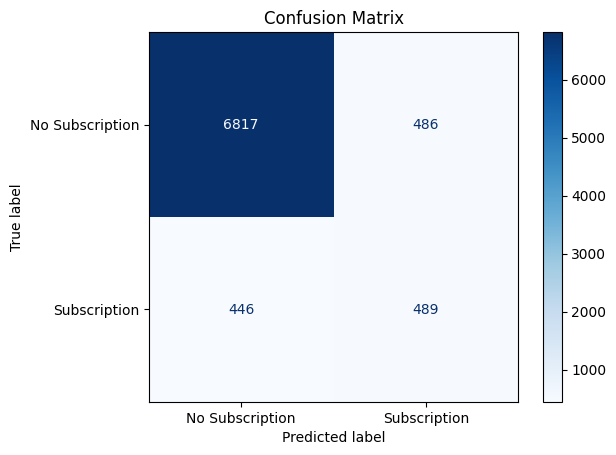

/tmp/ipython-input-723845746.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


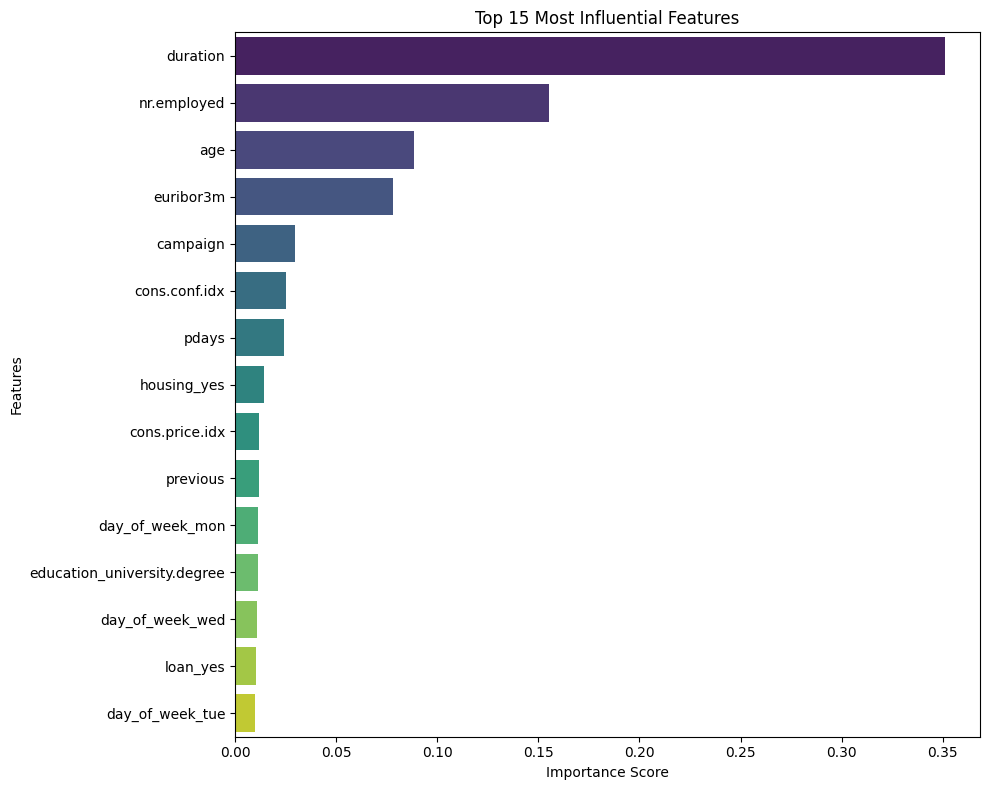

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Make predictions on the test set
y_pred = clf.predict(X_test)

# 2. Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# 3. Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Generate and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Subscription', 'Subscription'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# 5. Identify influential features
importances = clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort features by importance and take the top 15 for better visualization
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# 6. Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 15 Most Influential Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Load and Inspect Subset Dataset



In [ ]:
import pandas as pd

# 1. Load the subset dataset from the local path
file_path_subset = '/content/bank-additional.csv'
df_subset = pd.read_csv(file_path_subset, sep=';')

# 2. Display the first five rows
print("First 5 rows of the subset dataset:")
display(df_subset.head())

# 3. Inspect the dataset schema and data types
print("\nSubset Dataset Info:")
df_subset.info()

# 4. Review the statistical distribution of numerical features
print("\nSubset Summary Statistics:")
display(df_subset.describe())


First 5 rows of the subset dataset:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no



Subset Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.i

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Preprocess Subset Dataset




In [ ]:
# 1. Convert the target variable 'y' to numeric values in the subset dataset
df_subset['y'] = df_subset['y'].map({'yes': 1, 'no': 0})

# 2. Identify categorical features in the subset dataset
categorical_features_subset = df_subset.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features to encode in subset: {categorical_features_subset}")

# 3. Perform one-hot encoding on categorical features for the subset
df_subset_encoded = pd.get_dummies(df_subset, columns=categorical_features_subset, drop_first=True)

# 4. Create the feature matrix X_subset and target vector y_subset
X_subset = df_subset_encoded.drop('y', axis=1)
y_subset = df_subset_encoded['y']

# 5. Display the results
print("\nSubset preprocessing complete.")
print(f"Shape of feature matrix X_subset: {X_subset.shape}")
print(f"Shape of target vector y_subset: {y_subset.shape}")
print("\nFirst 5 rows of the encoded subset features:")
display(X_subset.head())

Categorical features to encode in subset: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Subset preprocessing complete.
Shape of feature matrix X_subset: (4119, 53)
Shape of target vector y_subset: (4119,)

First 5 rows of the encoded subset features:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,False,False,False,False,False,False,False,False,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False


## Comparative Visualization of Model Performance

In this section, we visually compare the results of the Decision Tree Classifier trained on the **Full Dataset** versus the **Subset Dataset**.

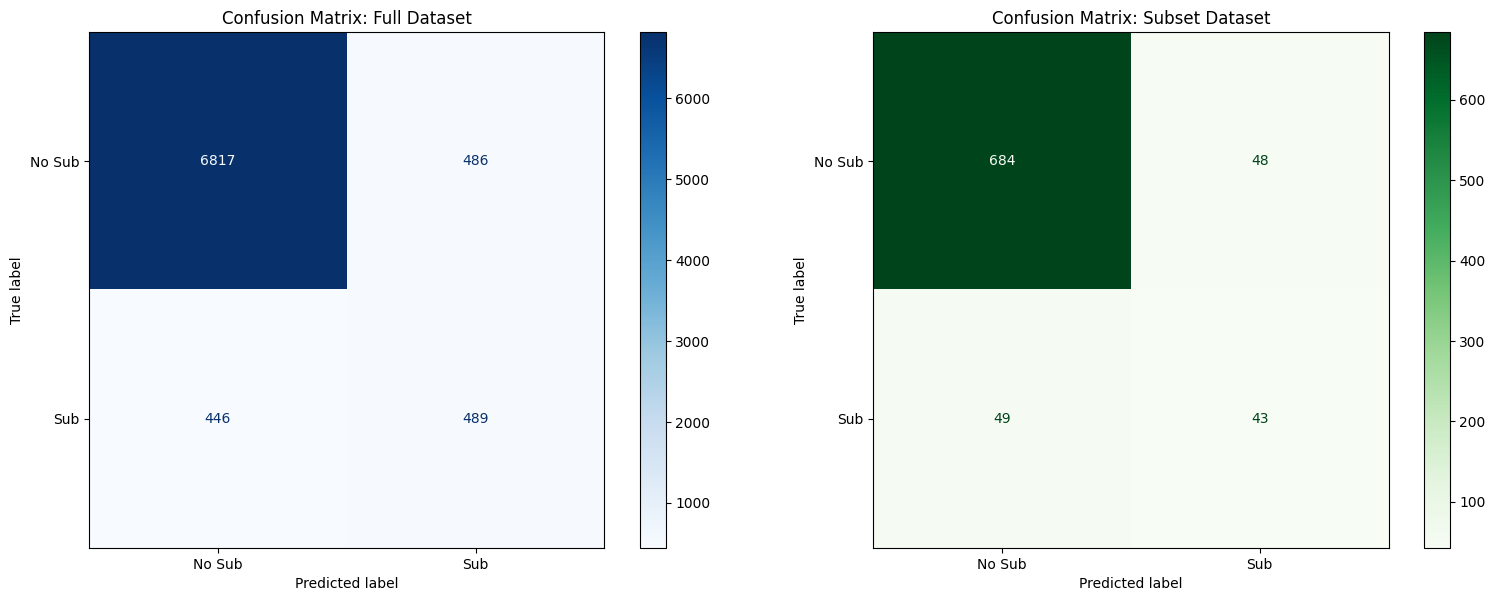

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# 1. Visualize Confusion Matrices side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Full Dataset Confusion Matrix
cm_full = confusion_matrix(y_test, y_pred)
disp_full = ConfusionMatrixDisplay(confusion_matrix=cm_full, display_labels=['No Sub', 'Sub'])
disp_full.plot(cmap=plt.cm.Blues, ax=ax1)
ax1.set_title('Confusion Matrix: Full Dataset')

# Subset Dataset Confusion Matrix
cm_sub = confusion_matrix(y_test_sub, y_pred_sub)
disp_sub = ConfusionMatrixDisplay(confusion_matrix=cm_sub, display_labels=['No Sub', 'Sub'])
disp_sub.plot(cmap=plt.cm.Greens, ax=ax2)
ax2.set_title('Confusion Matrix: Subset Dataset')

plt.tight_layout()
plt.show()

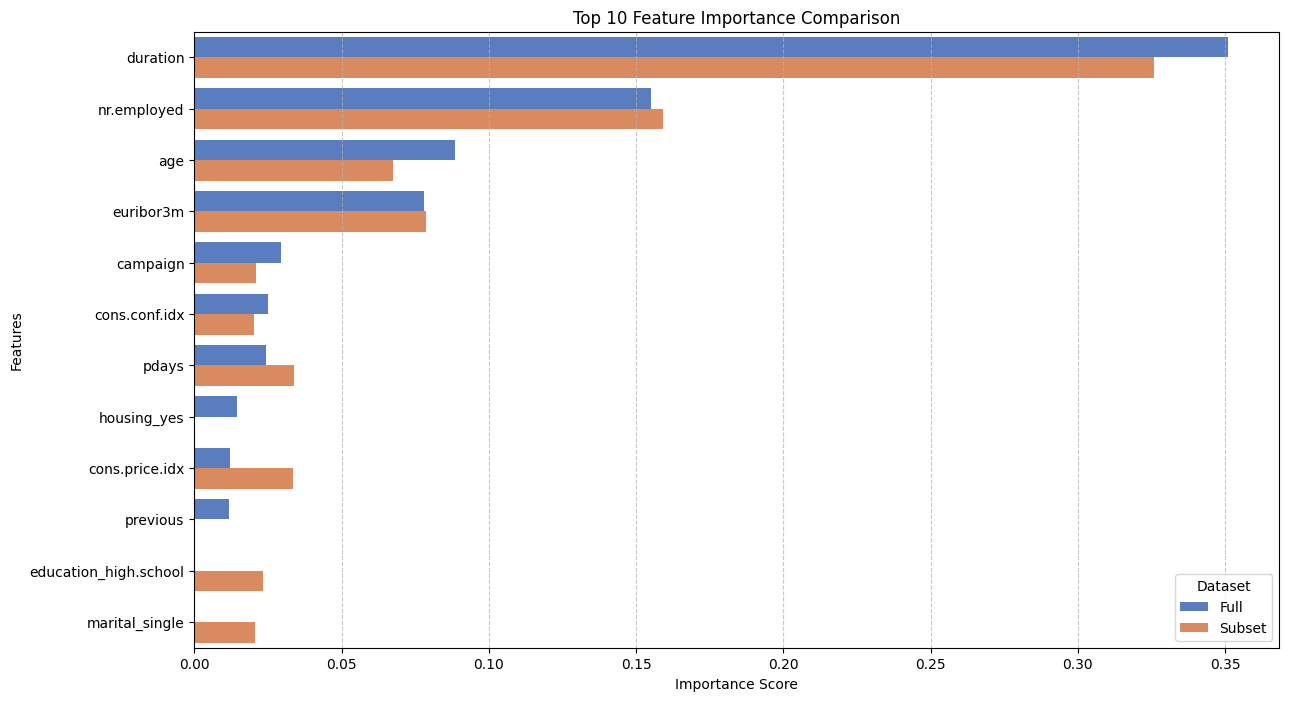

In [ ]:
# 2. Visualize Top 10 Feature Importances comparison
# Prepare data for plotting
importances_full = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_,
    'Dataset': 'Full'
}).sort_values('Importance', ascending=False).head(10)

importances_sub = pd.DataFrame({
    'Feature': X_subset.columns,
    'Importance': clf_subset.feature_importances_,
    'Dataset': 'Subset'
}).sort_values('Importance', ascending=False).head(10)

comparison_df = pd.concat([importances_full, importances_sub])

plt.figure(figsize=(14, 8))
sns.barplot(x='Importance', y='Feature', hue='Dataset', data=comparison_df, palette='muted')
plt.title('Top 10 Feature Importance Comparison')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

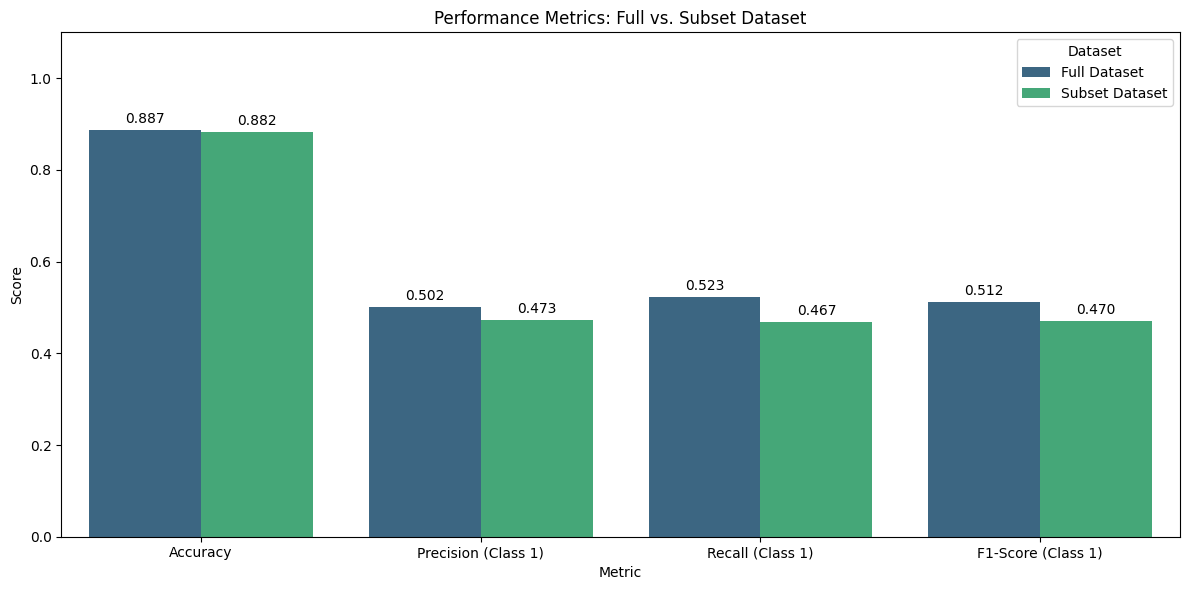

In [ ]:
# 3. Visualize Performance Metrics comparison
# We use the metrics_comparison dataframe created in the previous step
metrics_melted = metrics_comparison.melt(id_vars='Metric', var_name='Dataset', value_name='Value')

plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Value', hue='Dataset', data=metrics_melted, palette='viridis')
plt.title('Performance Metrics: Full vs. Subset Dataset')
plt.ylabel('Score')
plt.ylim(0, 1.1)  # Set y-axis limit for better clarity
for i in plt.gca().containers:
    plt.gca().bar_label(i, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

## Train and Evaluate Model on Subset




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Split the preprocessed subset data into training (80%) and testing (20%) sets
X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)

# 2. Initialize and train the Decision Tree Classifier on the subset
clf_subset = DecisionTreeClassifier(random_state=42)
clf_subset.fit(X_train_sub, y_train_sub)

# 3. Generate predictions and evaluate performance
y_pred_sub = clf_subset.predict(X_test_sub)
subset_accuracy = accuracy_score(y_test_sub, y_pred_sub)

print(f"Subset Accuracy Score: {subset_accuracy:.4f}")
print("\nSubset Classification Report:")
print(classification_report(y_test_sub, y_pred_sub))

# 4. Extract feature importances and identify the top 5
subset_importances = clf_subset.feature_importances_
subset_feature_importance_df = pd.DataFrame({'Feature': X_subset.columns, 'Importance': subset_importances})
subset_feature_importance_df = subset_feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

print("\nTop 5 Most Influential Features (Subset):")
print(subset_feature_importance_df)

Subset Accuracy Score: 0.8823

Subset Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       732
           1       0.47      0.47      0.47        92

    accuracy                           0.88       824
   macro avg       0.70      0.70      0.70       824
weighted avg       0.88      0.88      0.88       824


Top 5 Most Influential Features (Subset):
       Feature  Importance
1     duration    0.325757
9  nr.employed    0.159245
8    euribor3m    0.078779
0          age    0.067429
3        pdays    0.033959


## Tally and Compare Results

### Subtask:
Create comparison tables for the performance metrics and top features of the models trained on the full and subset datasets.


**Reasoning**:
I will generate classification reports for both datasets, construct a summary comparison table for performance metrics, and align the top 5 most influential features from both models for side-by-side visualization.



In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# 1. Generate classification reports as dictionaries
report_full = classification_report(y_test, y_pred, output_dict=True)
report_sub = classification_report(y_test_sub, y_pred_sub, output_dict=True)

# 2. Construct a summary DataFrame for performance metrics comparison
# Focus on Accuracy and Class 1 (Subscription) performance
metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)'],
    'Full Dataset': [
        report_full['accuracy'],
        report_full['1']['precision'],
        report_full['1']['recall'],
        report_full['1']['f1-score']
    ],
    'Subset Dataset': [
        report_sub['accuracy'],
        report_sub['1']['precision'],
        report_sub['1']['recall'],
        report_sub['1']['f1-score']
    ]
})

print("Performance Metrics Comparison:")
display(metrics_comparison)

# 3. Prepare top 5 features for comparison
# resetting index for side-by-side concatenation
top_5_full = feature_importance_df.head(5).reset_index(drop=True)
top_5_sub = subset_feature_importance_df.head(5).reset_index(drop=True)

# Rename columns to distinguish between models
top_5_full.columns = ['Feature (Full)', 'Importance (Full)']
top_5_sub.columns = ['Feature (Subset)', 'Importance (Subset)']

# 4. Display the feature comparison table
feature_comparison = pd.concat([top_5_full, top_5_sub], axis=1)
print("\nTop 5 Features Comparison:")
display(feature_comparison)

Performance Metrics Comparison:


,Metric,Full Dataset,Subset Dataset
0,Accuracy,0.886866,0.882282
1,Precision (Class 1),0.501538,0.472527
2,Recall (Class 1),0.522995,0.467391
3,F1-Score (Class 1),0.512042,0.469945



Top 5 Features Comparison:


,Feature (Full),Importance (Full),Feature (Subset),Importance (Subset)
0,duration,0.350887,duration,0.325757
1,nr.employed,0.155049,nr.employed,0.159245
2,age,0.088462,euribor3m,0.078779
3,euribor3m,0.077975,age,0.067429
4,campaign,0.029592,pdays,0.033959


## Summary:

### Q&A

**Did the smaller subset provide consistent results compared to the full dataset?**
Yes, the results were highly consistent. Both models achieved similar overall accuracy (88.69% for the full dataset vs. 88.23% for the subset). Furthermore, the top four most influential features identified by the Decision Tree were the same across both models, indicating that the subset effectively captured the core relationships in the data.

### Data Analysis Key Findings

*   **Model Performance Consistency**: The model trained on the subset (4,119 rows) maintained an accuracy of **88.23%**, which is only slightly lower than the **88.69%** achieved by the full dataset model.
*   **Minority Class Challenges**: Predicting successful subscriptions (Class 1) was more difficult for the smaller dataset. The F1-score for Class 1 dropped from **0.512** (Full) to **0.470** (Subset), suggesting that more data helps the model better understand the characteristics of the minority class.
*   **Feature Importance Alignment**: Both models identified **duration** (approx. 33-35% importance) and **nr.employed** (approx. 15-16% importance) as the two most critical predictors for whether a customer would subscribe.
*   **Shared Top Features**: Four out of the top five features were identical between the models: **duration**, **nr.employed**, **age**, and **euribor3m**. The subset model prioritized **pdays** (number of days since last contact) as its fifth feature, while the full model prioritized **campaign** (number of contacts during this campaign).

